# 01: Least Squares From the Mean

## Learning objectives
- Define an objective function for model fitting.
- Show that minimizing squared residuals gives the sample mean.
- Interpret residuals and misfit plots.

## Why this matters for inverse theory
In inverse problems, we choose model parameters to best explain observations.

A very simple case is one unknown value $m$ that explains data $d_i$ as:

$$d_i = m + e_i$$

where $e_i$ is the residual (error).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Keep plotting simple and readable
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

## Example data
We will treat these as repeated measurements of one quantity.

In [17]:
d = np.array([2.1, 1.9, 2.6, 2.0, 1.8, 2.2, 2.4])
print('Data:', d)
print('Number of observations:', len(d))

Data: [2.1 1.9 2.6 2.  1.8 2.2 2.4]
Number of observations: 7


## Define least-squares misfit
For a trial model value $m$, residuals are $r_i = d_i - m$.

Least-squares objective:

$$J(m) = \sum_{i=1}^N (d_i - m)^2$$

In [18]:
def J(m, data):
    residuals = data - m
    return np.sum(residuals**2)

## Visualize the objective function

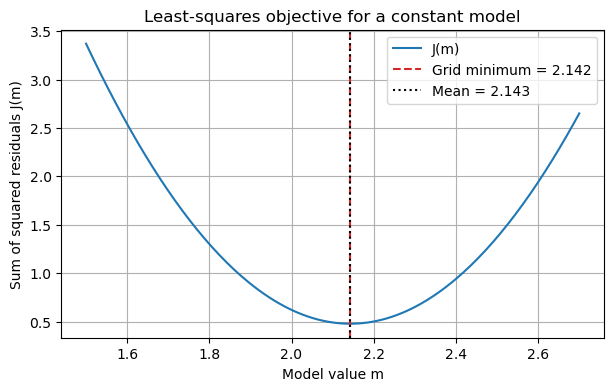

In [19]:
m_grid = np.linspace(1.5, 2.7, 201)
J_grid = np.array([J(m, d) for m in m_grid])

m_best_grid = m_grid[np.argmin(J_grid)]
m_mean = np.mean(d)

fig, ax = plt.subplots()
ax.plot(m_grid, J_grid, label='J(m)')
ax.axvline(m_best_grid, color='tab:red', linestyle='--', label=f'Grid minimum = {m_best_grid:.3f}')
ax.axvline(m_mean, color='k', linestyle=':', label=f'Mean = {m_mean:.3f}')
ax.set_xlabel('Model value m')
ax.set_ylabel('Sum of squared residuals J(m)')
ax.set_title('Least-squares objective for a constant model')
ax.legend()
plt.show()

## Derivation
Set derivative to zero:

$$\frac{dJ}{dm} = \frac{d}{dm}\sum_{i=1}^N (d_i - m)^2 = -2\sum_{i=1}^N (d_i - m)=0$$

So:

$$\sum d_i - Nm = 0 \Rightarrow m = \frac{1}{N}\sum d_i$$

The least-squares solution is the sample mean.

In [20]:
print(f'Mean from numpy: {m_mean:.6f}')
print(f'Least squares solution: {np.sum(d)/len(d):.6f}')
print(f'Grid-search minimum: {m_best_grid:.6f}')

Mean from numpy: 2.142857
Least squares solution: 2.142857
Grid-search minimum: 2.142000


Note that the grid-search result is slightly less accurate; this depends on how finely spaced our grid search samples were.

## Residual interpretation
A good fit has small residuals (close to zero) without obvious bias.

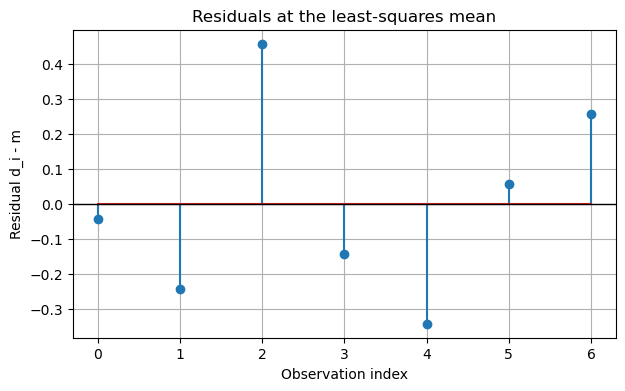

Sum of residuals: -2.4424906541753444e-15
Sum of squared residuals: 0.4771428571428572


In [21]:
residuals = d - m_mean

fig, ax = plt.subplots()
ax.stem(np.arange(len(d)), residuals)
ax.axhline(0, color='k', linewidth=1)
ax.set_xlabel('Observation index')
ax.set_ylabel('Residual d_i - m')
ax.set_title('Residuals at the least-squares mean')
plt.show()

print('Sum of residuals:', np.sum(residuals))
print('Sum of squared residuals:', np.sum(residuals**2))

## Exercise (TODO)
1. Replace `d` with a new dataset of your choice.
2. Recompute the mean and residual plot.
3. Add one large outlier and observe how the mean changes.

Write 2-3 sentences: why is least squares sensitive to outliers?

## Checkpoint questions
1. Why do we square residuals instead of summing signed residuals?
2. What does the curvature of $J(m)$ near its minimum imply about uncertainty?
3. If all data values are shifted up by +1, what happens to the least-squares solution?

## Summary
- We framed fitting as minimizing an objective function.
- For a constant model, least squares gives the arithmetic mean.
- This is the simplest inverse problem and the basis for matrix least squares in the next notebook.